In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from sqlalchemy import create_engine
from sqlalchemy.orm import declarative_base, sessionmaker

In [7]:
data = pd.read_csv("../data/raw/me_cfs_vs_depression_dataset.csv")

In [8]:
data.head()

,age,gender,sleep_quality_index,brain_fog_level,physical_pain_score,stress_level,depression_phq9_score,fatigue_severity_scale_score,pem_duration_hours,hours_of_sleep_per_night,pem_present,work_status,social_activity_level,exercise_frequency,meditation_or_mindfulness,diagnosis
0,56,Male,8.7,3.9,9.2,8.1,10.0,6.5,9.0,7.7,0,Working,Low,Daily,Yes,Depression
1,69,Male,1.3,9.9,4.2,9.9,20.0,7.0,41.0,8.4,1,Working,Low,Often,Yes,Both
2,46,Female,4.0,5.4,4.8,NaN,24.0,1.6,13.0,6.9,0,Partially working,NaN,Rarely,Yes,Depression
3,32,Female,9.4,2.1,2.9,3.8,10.0,6.8,11.0,7.5,0,Not working,High,Never,Yes,Depression
4,60,Female,7.6,7.5,6.4,8.5,17.0,7.0,46.0,3.1,1,Not working,Low,Rarely,No,Both


- a. Replace missing values if present and justify the choice

In [9]:
missing_values = data.isnull().sum()
missing_values

age                              0
gender                           0
sleep_quality_index             47
brain_fog_level                 48
physical_pain_score             34
stress_level                    48
depression_phq9_score           22
fatigue_severity_scale_score    21
pem_duration_hours              24
hours_of_sleep_per_night        21
pem_present                      0
work_status                     47
social_activity_level           40
exercise_frequency              39
meditation_or_mindfulness       11
diagnosis                        0
dtype: int64

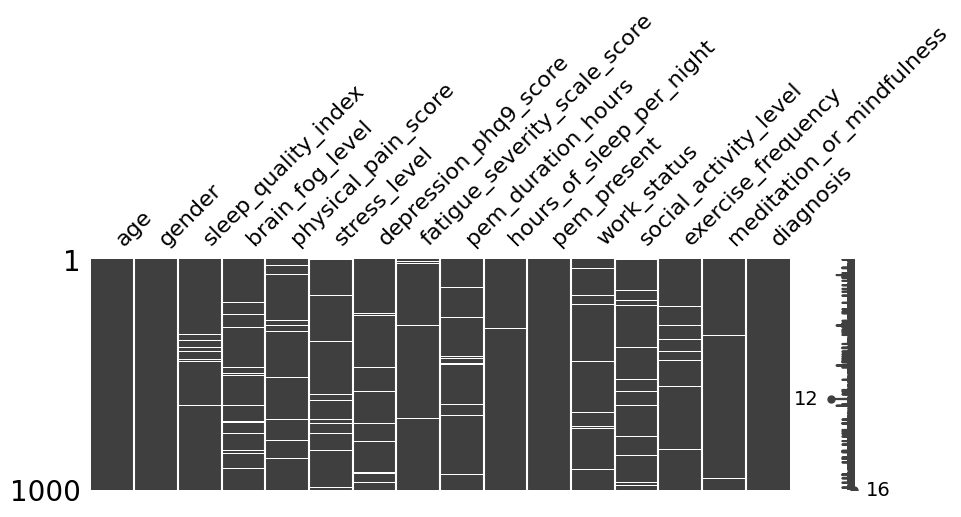

In [10]:
msno.matrix(data, figsize=(10,3))
plt.show()

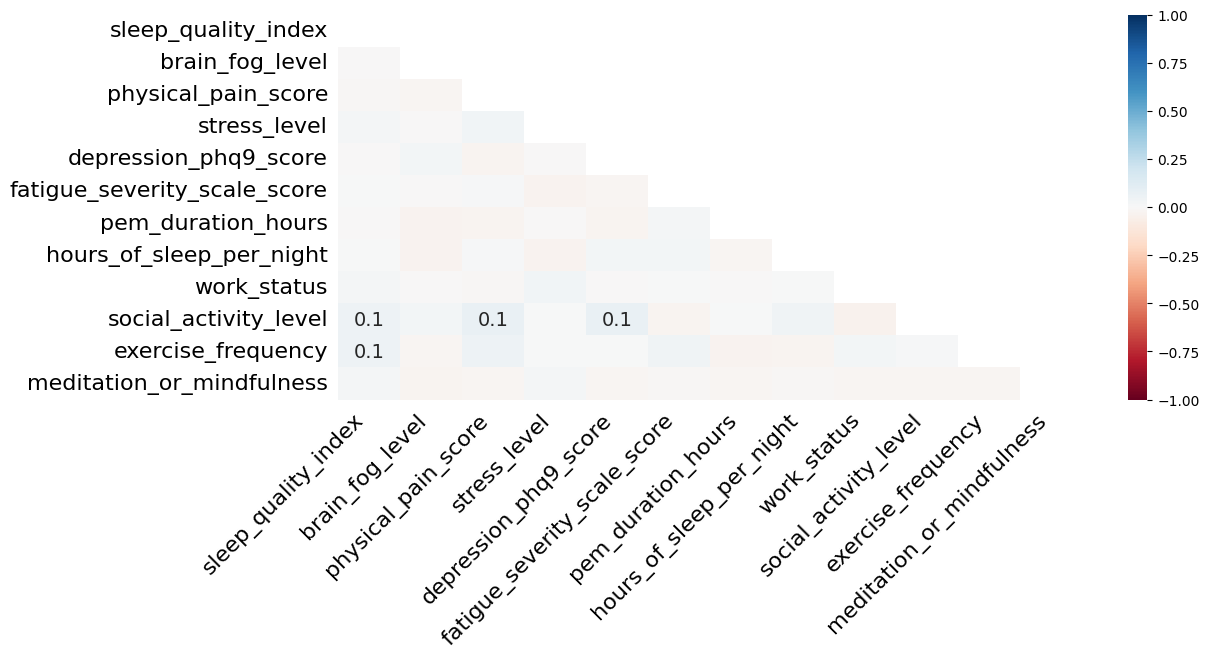

In [11]:
msno.heatmap(data, figsize=(12,5))
plt.show()

In [12]:
missing_percantege = (missing_values / len(data)) * 100
missing_percantege

age                             0.0
gender                          0.0
sleep_quality_index             4.7
brain_fog_level                 4.8
physical_pain_score             3.4
stress_level                    4.8
depression_phq9_score           2.2
fatigue_severity_scale_score    2.1
pem_duration_hours              2.4
hours_of_sleep_per_night        2.1
pem_present                     0.0
work_status                     4.7
social_activity_level           4.0
exercise_frequency              3.9
meditation_or_mindfulness       1.1
diagnosis                       0.0
dtype: float64

In [13]:
total_missing = missing_values.sum()
total_data = len(data.columns) * len(data)

print(f"Number of missing values: {total_missing}/{total_data}")
print(f"Percentage of missing values: {(total_missing * 100) / total_data}%")

Кількість відсутніх даних: 402/16000
Відсоток відсутніх даних: 2.5125%


C:\Users\Admin\AppData\Local\Temp\ipykernel_10020\1859164953.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)


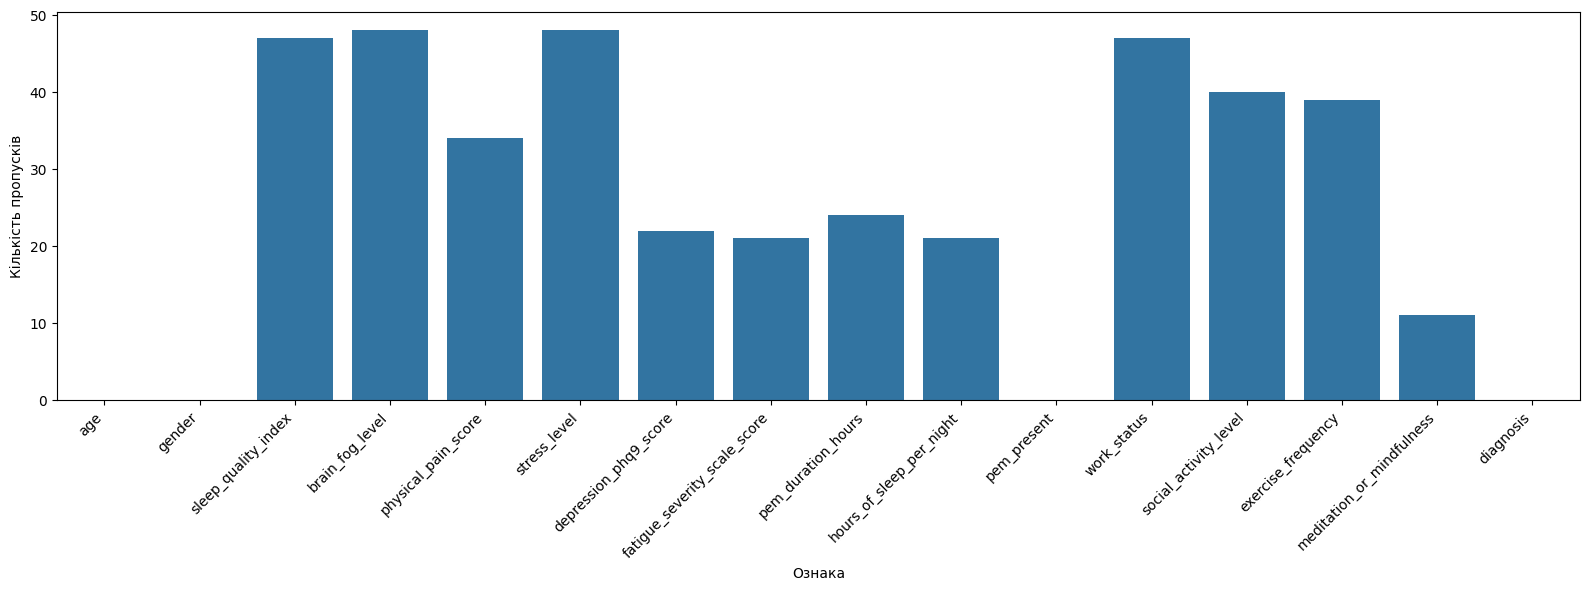

In [14]:
_, ax = plt.subplots(figsize=(16, 6))
sns.barplot(x=missing_values.index, y=missing_values.values, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Count of missing values')
ax.set_xlabel('Feature')
plt.tight_layout()
plt.show()

In [15]:
missing_columns = missing_values[missing_values != 0]
missing_columns

sleep_quality_index             47
brain_fog_level                 48
physical_pain_score             34
stress_level                    48
depression_phq9_score           22
fatigue_severity_scale_score    21
pem_duration_hours              24
hours_of_sleep_per_night        21
work_status                     47
social_activity_level           40
exercise_frequency              39
meditation_or_mindfulness       11
dtype: int64

In [16]:
quantitative_features = data.select_dtypes(include=["int64", "float64"]).columns
quantitative_miss_index = missing_columns.index.intersection(quantitative_features)

missing_columns[quantitative_miss_index]

sleep_quality_index             47
brain_fog_level                 48
physical_pain_score             34
stress_level                    48
depression_phq9_score           22
fatigue_severity_scale_score    21
pem_duration_hours              24
hours_of_sleep_per_night        21
dtype: int64

In [17]:
qualitative_features = data.select_dtypes(include=["object", "category"]).columns
qualitative_miss_index = missing_columns.index.intersection(qualitative_features)

missing_columns[qualitative_miss_index]

work_status                  47
social_activity_level        40
exercise_frequency           39
meditation_or_mindfulness    11
dtype: int64

In [18]:
def plot_quantitative_histplots():
    n = len(quantitative_features)
    n_cols = min(3, n)
    n_rows = int(np.ceil(n / n_cols))

    fig, ax = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))

    if n_rows * n_cols == 1:
        ax = [ax] 
    else:
        ax = ax.flatten()

    for i, x in enumerate(quantitative_features):
        sns.histplot(data=data, x=x, kde=True, color="skyblue", ax=ax[i])
        ax[i].set_title(x)

    for j in range(n, n_rows * n_cols):
        ax[j].set_visible(False)

    plt.tight_layout()
    plt.show()

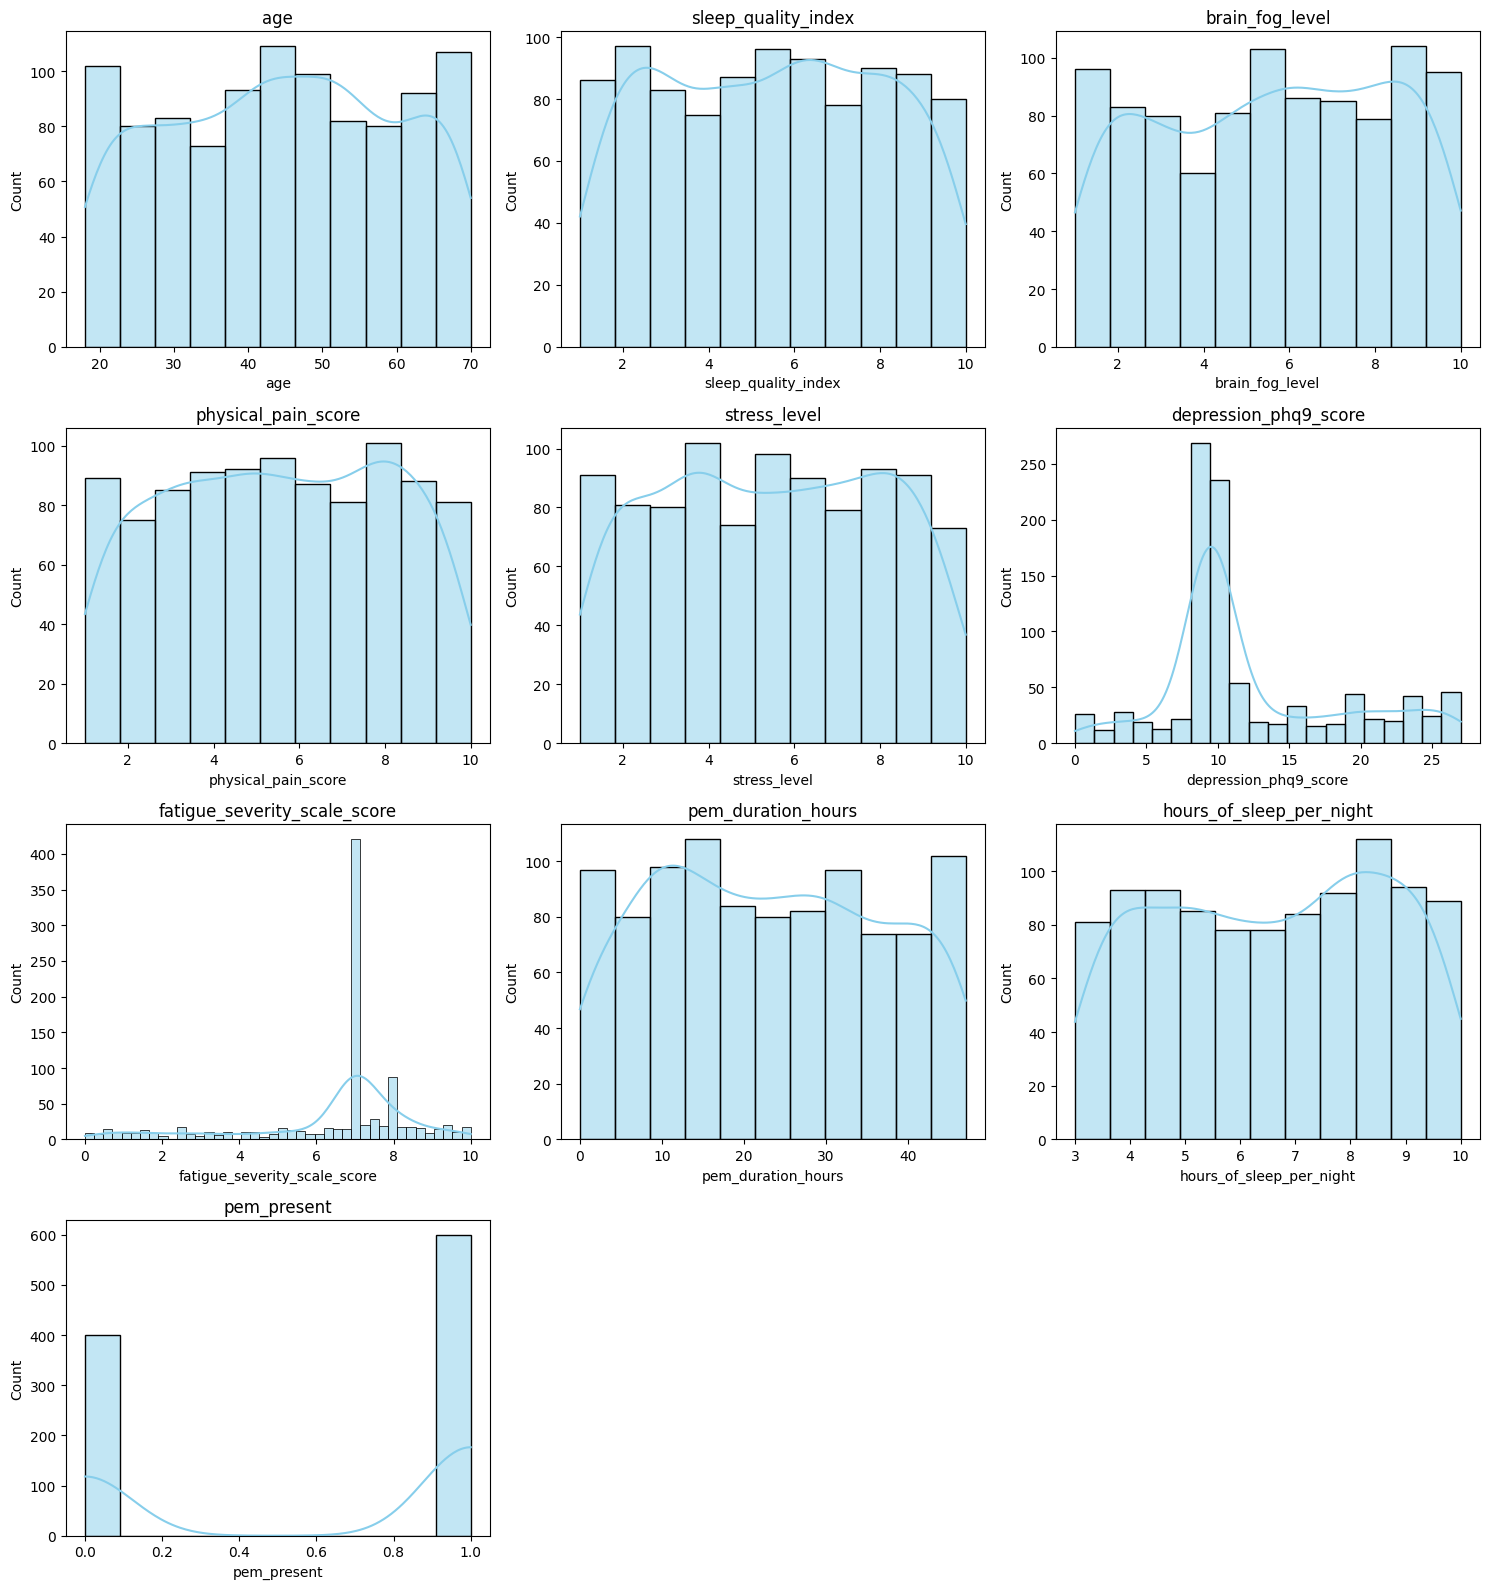

In [19]:
plot_quantitative_histplots()

In [20]:
def plot_quantitative_boxplots():
    n = len(quantitative_features)
    n_cols = min(3, n)
    n_rows = int(np.ceil(n / n_cols))

    fig, ax = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))

    if n_rows * n_cols == 1:
        ax = [ax] 
    else:
        ax = ax.flatten()

    for i, x in enumerate(quantitative_features):
        sns.boxplot(data=data, x=x, color="skyblue", ax=ax[i])
        ax[i].set_title(x)

    for j in range(n, n_rows * n_cols):
        ax[j].set_visible(False)

    plt.tight_layout()
    plt.show()

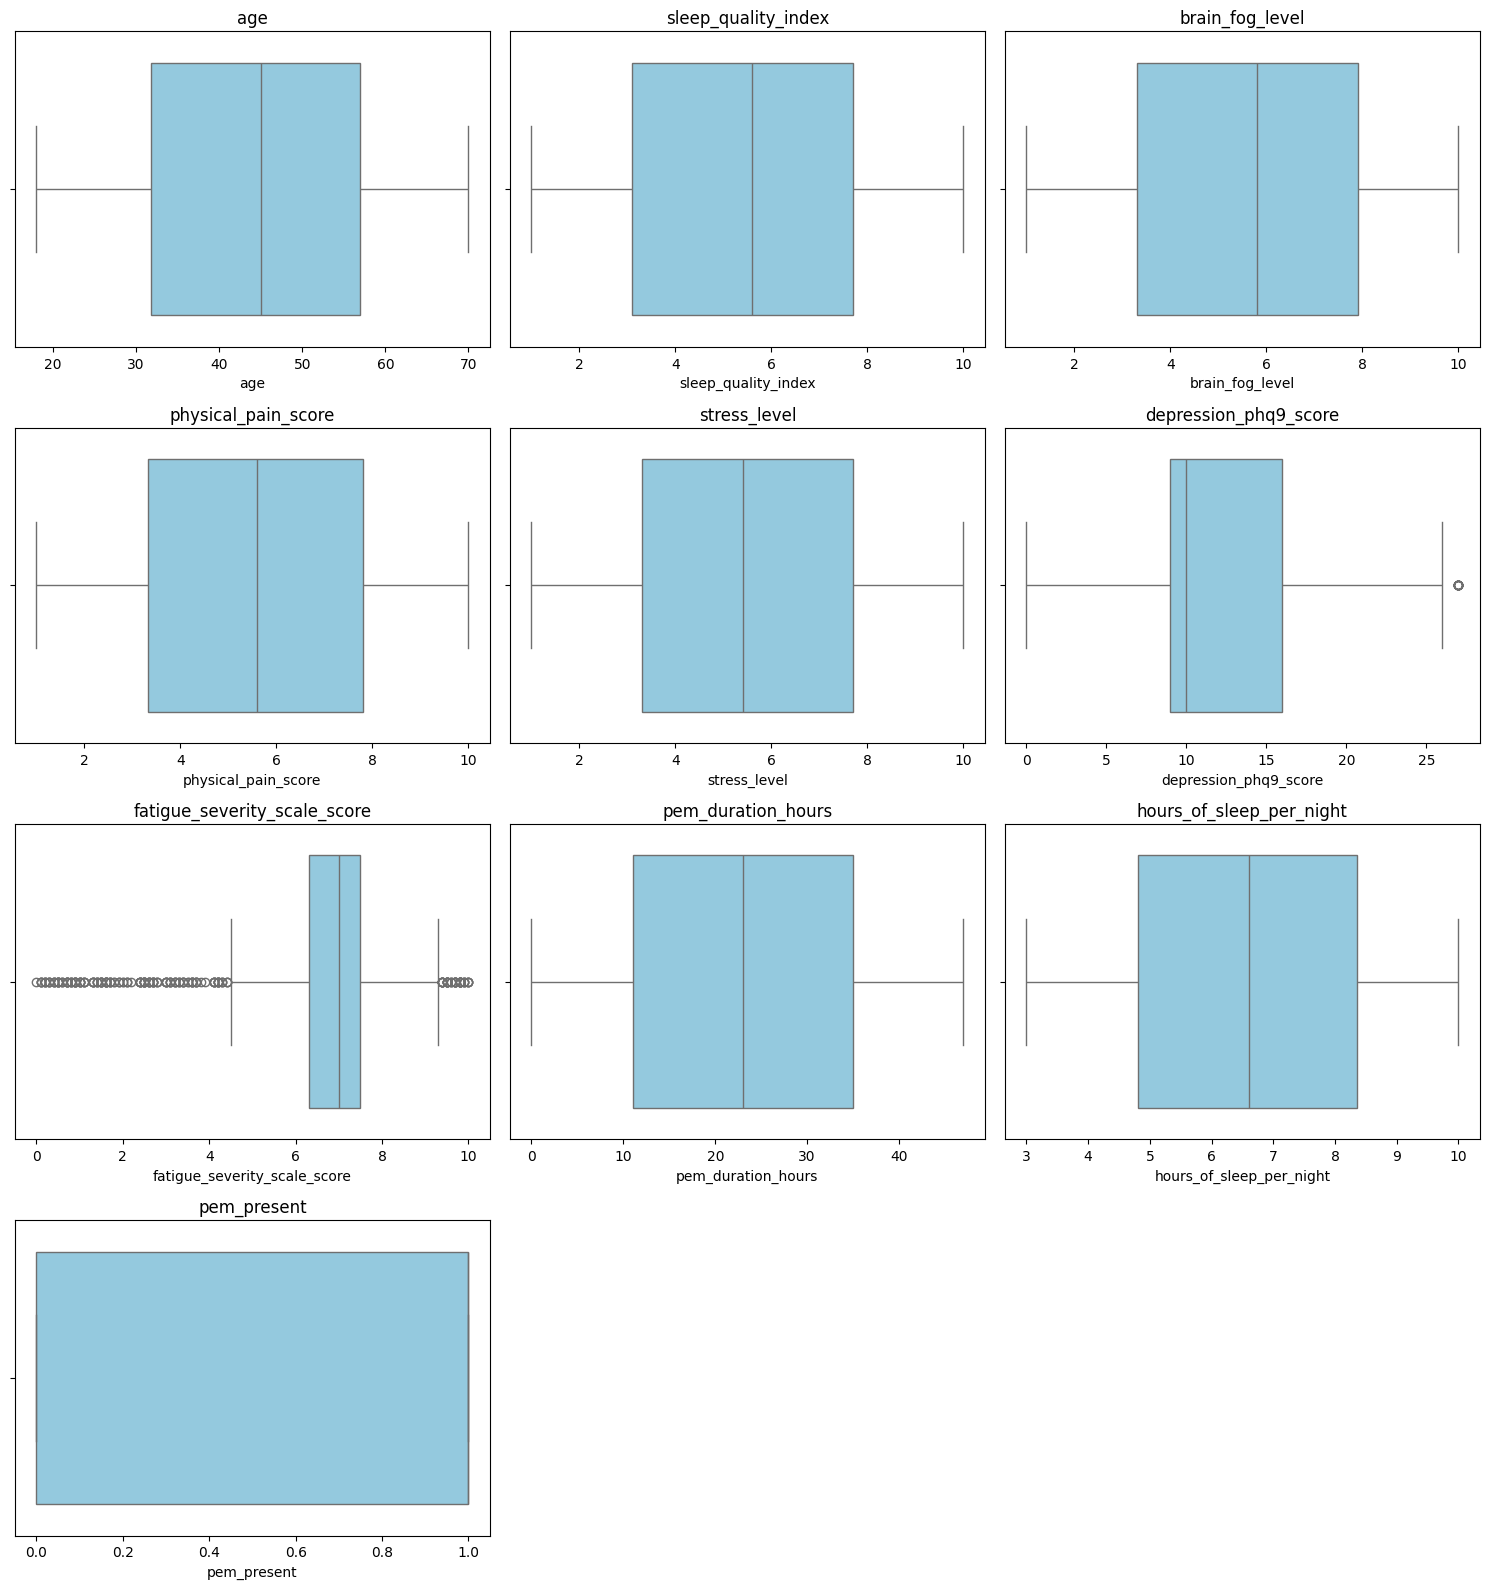

In [21]:
plot_quantitative_boxplots()

Now, after checking the distribution of each numerical column and checking for the presence of outliers in them, we can analyze how to impute the data:
- In the features `fatigue_severity_scale_score` and `depression_phq9_score` we see outliers, which indicates that using a mean imputer for them would be a poor decision. A much better solution is to use a median imputer.
- Regarding other plots: they do not have outliers, but they are not normally distributed either. The optimal solution will also be to use a median imputer.

In [22]:
for feature in quantitative_features:
  print(data[feature].mean())
  print(data[feature].median())
  print(" ")


44.385
45.0
 
5.4686253934942295
5.6
 
5.6117647058823525
5.8
 
5.52184265010352
5.6
 
5.459138655462185
5.4
 
12.268916155419223
10.0
 
6.407252298263535
7.0
 
23.105532786885245
23.0
 
6.571297242083759
6.6
 
0.599
1.0
 


In [23]:
def median_imputer(data, x):
    median = data[x].median()
    data.loc[data[x].isna(), x] = median

In [24]:
for x in quantitative_features:
  median_imputer(data, x)

In [25]:
data[quantitative_features].isna().sum()

age                             0
sleep_quality_index             0
brain_fog_level                 0
physical_pain_score             0
stress_level                    0
depression_phq9_score           0
fatigue_severity_scale_score    0
pem_duration_hours              0
hours_of_sleep_per_night        0
pem_present                     0
dtype: int64

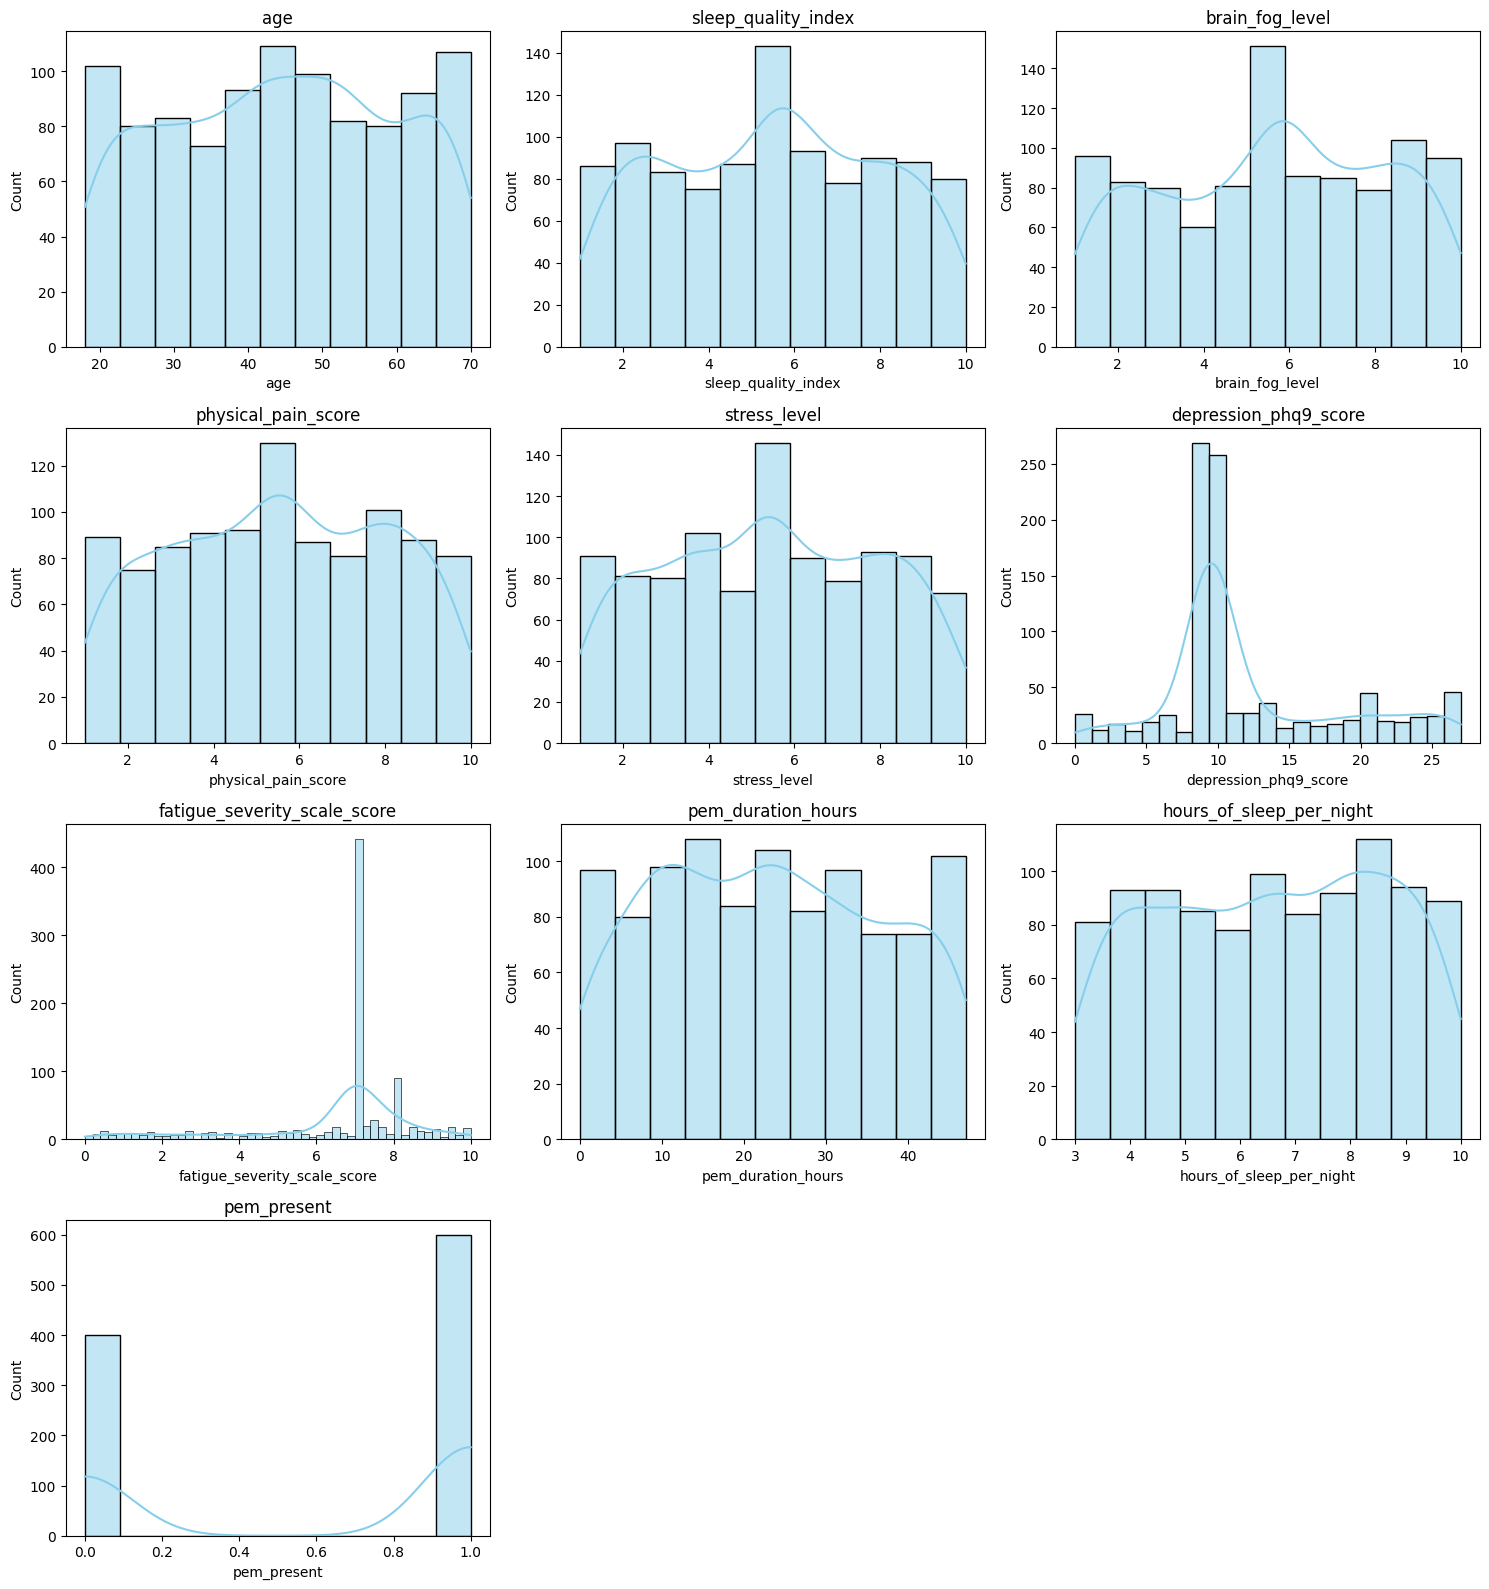

In [26]:
plot_quantitative_histplots()

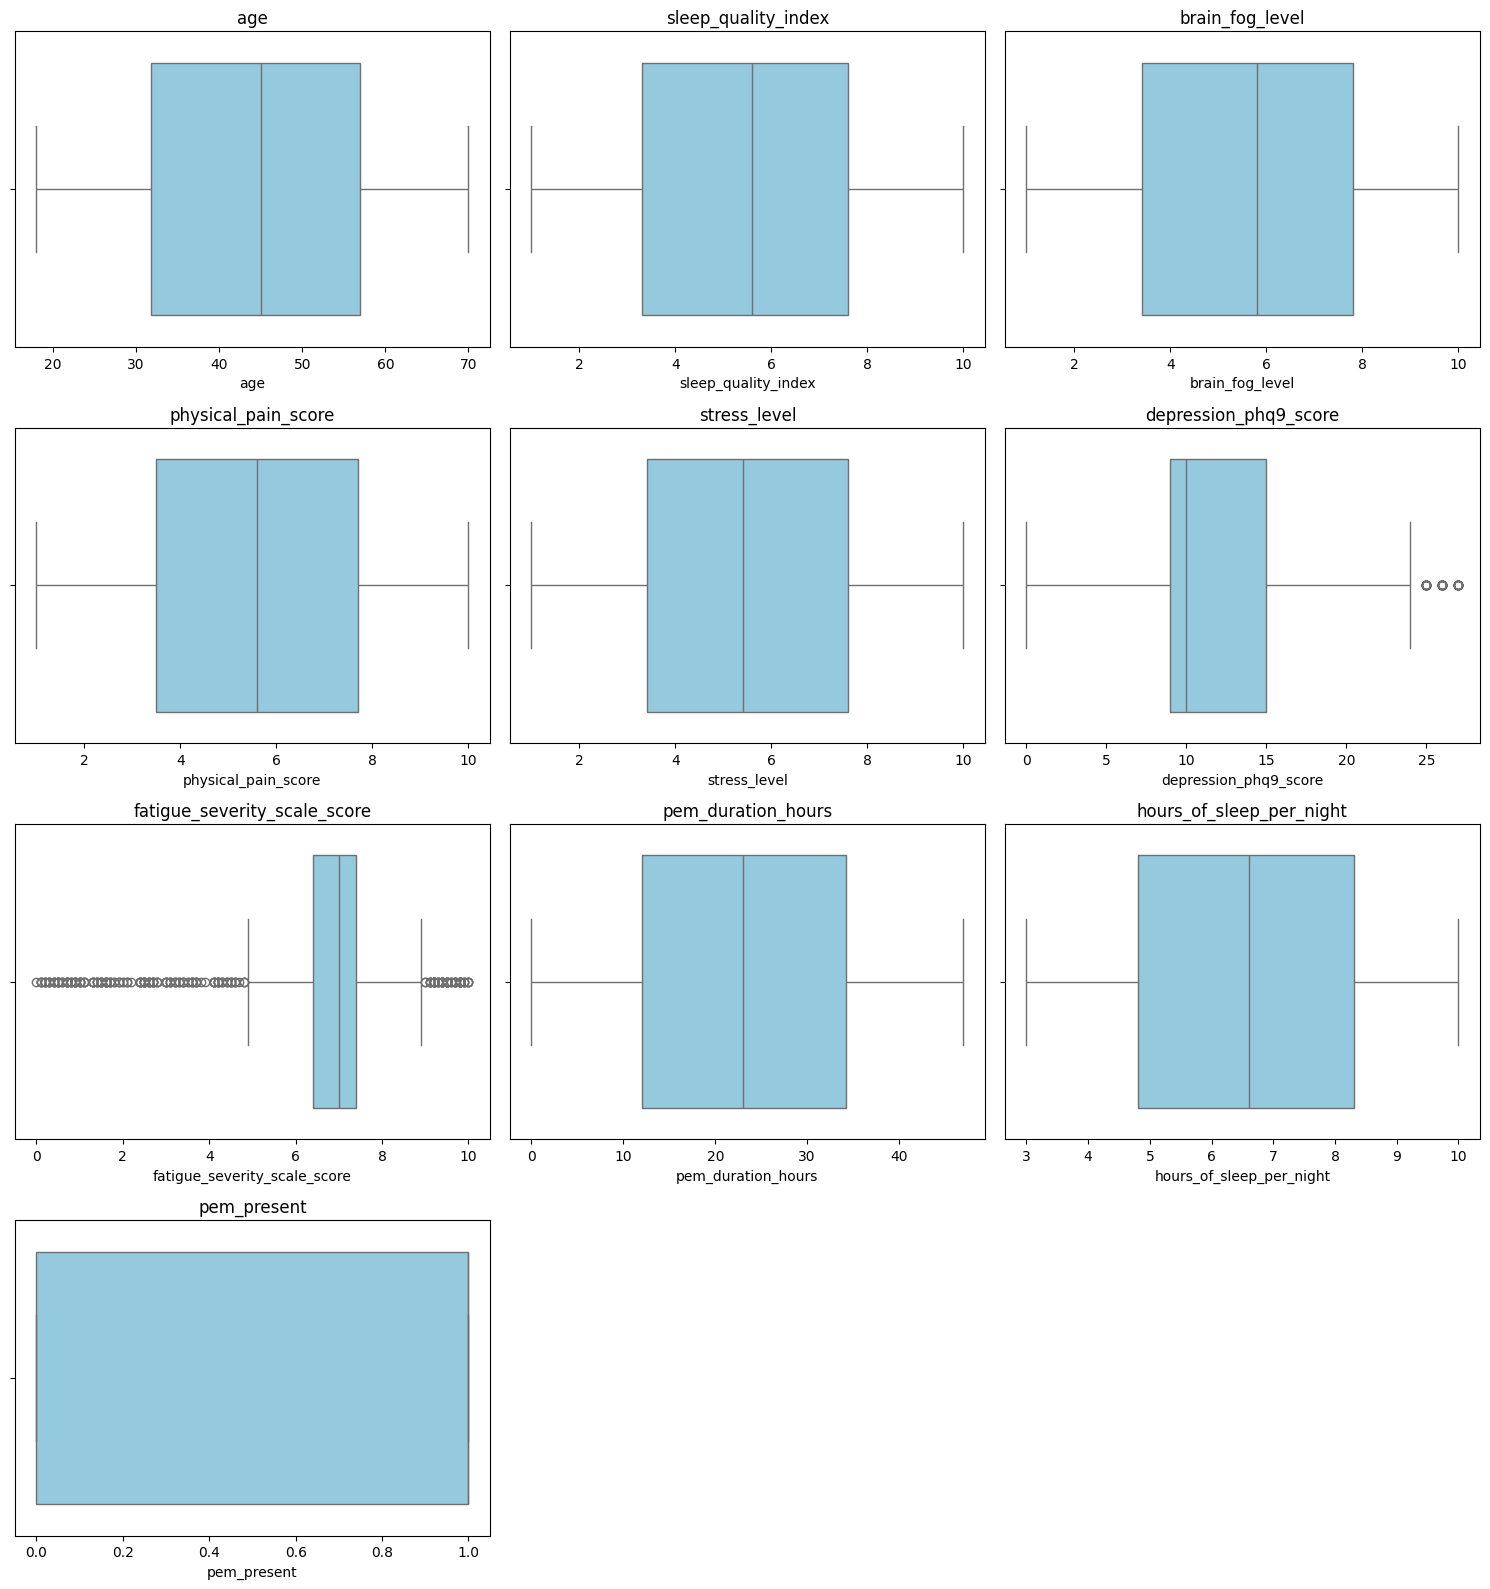

In [27]:
plot_quantitative_boxplots()

Having finished with numerical features, I will move on to categorical ones.

In [28]:
qualitative_miss_cols = data[qualitative_miss_index].columns

In [29]:
def plot_qualitative_barlots():
    n = len(qualitative_miss_cols)
    n_cols = min(3, n)
    n_rows = int(np.ceil(n / n_cols))

    fig, ax = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))

    if n_rows * n_cols == 1:
        ax = [ax] 
    else:
        ax = ax.flatten()

    for i, x in enumerate(qualitative_miss_cols):
        sns.countplot(data=data, x=x, color="skyblue", ax=ax[i])
        ax[i].set_title(x)

    for j in range(n, n_rows * n_cols):
        ax[j].set_visible(False)

    plt.tight_layout()
    plt.show()

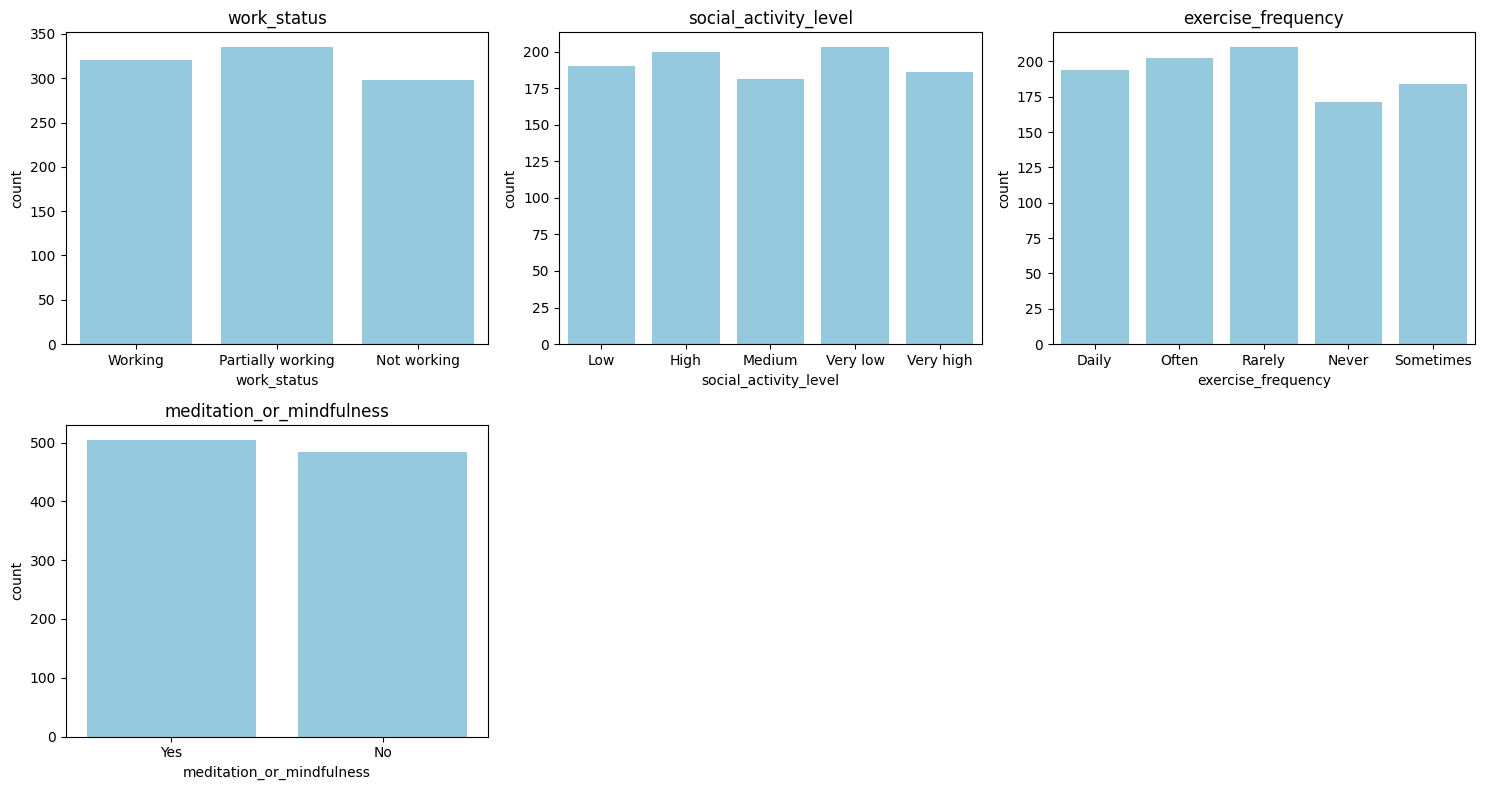

In [30]:
plot_qualitative_barlots()

In principle, all categories in the columns are distributed roughly equally, so I will choose mode imputation, which essentially means imputing the most frequent category into empty cells.

In [31]:
def mode_imputation(data, x):
  most_frequent_category = data[x].value_counts().idxmax()
  data.loc[data[x].isna(), x] = most_frequent_category

In [32]:
for x in qualitative_miss_cols:
  mode_imputation(data, x)

In [33]:
data.isna().sum()

age                             0
gender                          0
sleep_quality_index             0
brain_fog_level                 0
physical_pain_score             0
stress_level                    0
depression_phq9_score           0
fatigue_severity_scale_score    0
pem_duration_hours              0
hours_of_sleep_per_night        0
pem_present                     0
work_status                     0
social_activity_level           0
exercise_frequency              0
meditation_or_mindfulness       0
diagnosis                       0
dtype: int64

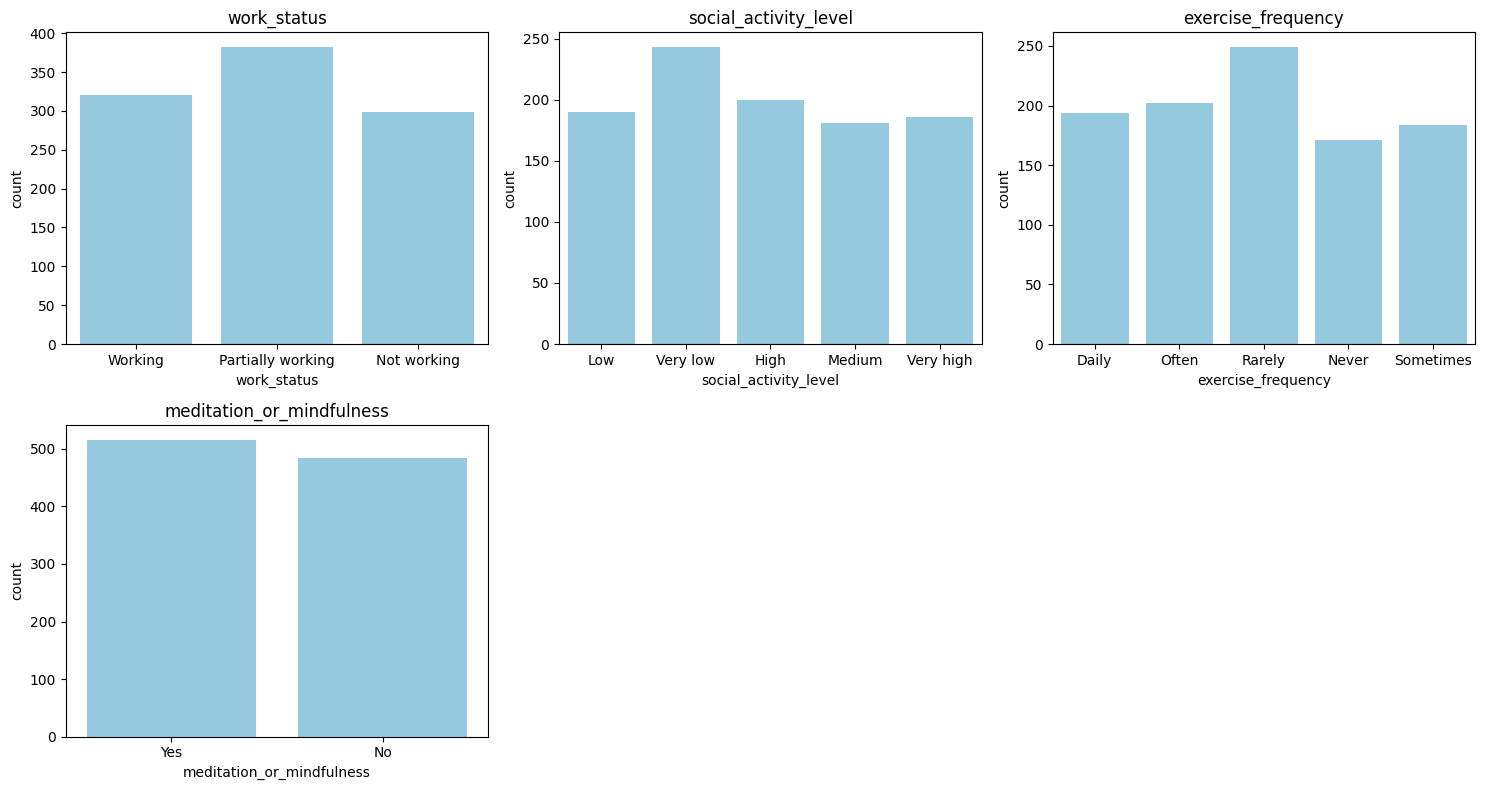

In [34]:
plot_qualitative_barlots()

In [35]:
data.to_csv("../data/processed/cleaning_data.csv", index=False)